# Drone Görüntülerinde Araç Tespiti · YOLO11m

**LEVEL-UP AI | ROKETSAN Yapay Zekâ Hackathonu · Aşama 1**

| | |
|---|---|
| **Görev** | Drone görüntülerinde alanı ≥ 200 px² olan araçları tespit edip `car`, `van`, `truck`, `bus` olarak sınıflandırmak |
| **Metrik** | mAP@0.5 (dört sınıfın AP ortalaması, her sınıf eşit ağırlıklı) |
| **Model** | YOLO11m (Ultralytics), COCO ön-eğitimli. Tarif, YOLO11s baseline'ı ile birebir aynı; fark yalnızca model boyutu. |
| **Doğrulama** | `splits/scene_holdout_v2`: sahne grupları bölünmeden, test dağılımına göre katmanlanmış 1.295 görüntü |
| **Donanım** | Kaggle, 2× NVIDIA T4 (DDP) |

Bu notebook baştan sona **Run All** ile çalışır: veriyi hazırlar, modeli eğitir, yarışma metriğiyle değerlendirir, dört tahmin yöntemini doğrulama kümesinde karşılaştırır ve kazanan yöntemle `submission.csv` üretir.

### İçindekiler
1. [Ortam ve yapılandırma](#1)
2. [Veri seti](#2)
3. [Sınıf dengesizliği: Repeat Factor Sampling](#3)
4. [LR'ye bağlı azalan veri artırımı](#4)
5. [Eğitim](#5)
6. [Eğitim geçmişi](#6)
7. [Değerlendirme](#7)
8. [Tahmin iyileştirmeleri: çözünürlük, TTA, SAHI](#8)
9. [Test tahmini ve submission](#9)
10. [Özet](#10)

## Tasarım kararları ve dayanakları

Kararlar keşifsel veri analizine (`hakan/notebooks/01_eda.ipynb`, `furkan/notebooks/01b_eda_addendum.ipynb`) dayanır.
Doğrulanmamış varsayımlara dayanan ayarlar eklenmemiş, bunlar için Ultralytics varsayılanları korunmuştur.

| Karar | Değer | Dayanak |
|---|---|---|
| Giriş çözünürlüğü | `imgsz=1280` | Kısa kenarı 16 px'in altına düşen kutular: 960'ta %38, 1280'de %20 |
| Dikey çevirme | `flipud=0` | Eğik çekim perspektifi: nesne boyutu görüntünün üstünden altına 2,4 kat artıyor (Spearman ρ = 0,38) |
| Yatay çevirme | `fliplr=0.5` | Sahnede sol-sağ simetrisi korunuyor |
| Sınıf dengesizliği | Repeat Factor Sampling | Kutu payları car %75 · van %14 · truck %7 · bus %3; mAP'te her sınıf %25 ağırlıklı |
| Veri artırımı takvimi | LR ile azalan, **en düşük %60** (11s'te %30), son 10 epoch mosaic kapalı | 11s'te val sınıflandırma kaybı ~30. epoch'tan sonra yükseldi (aşırı öğrenme); daha büyük model için düzenlileştirme güçlü tutuldu |
| Parlaklık artırımı | `hsv_v=0.5`, **azaltılmıyor** | 11s'te karanlık görüntülerde mAP 0,632 (genel 0,738), van AP 0,375; testin %22'si karanlık |
| Tahmin eşikleri | `conf=0.001`, `max_det=1000` | Yarışma kuralı: düşük güvenli kutular cezalandırılmaz; görüntü başına en fazla 218 kutu |
| Doğrulama ağırlıkları | Çözünürlük × aydınlatma katmanları | Test dağılımı train'den farklı (1400×788 testin %44'ü, bunların %45'i karanlık) |
| Early stopping | Kapalı | Süre bütçeli cosine takvimin düşük LR evresi korunur; `last.pt` ve `best.pt` sonda karşılaştırılır |
| Tahmin yöntemi | 1280 · 1536 · TTA@1536 · SAHI | Doğrulama kümesinde yarışma metriğiyle ölçülerek seçilir (Bölüm 8) |
| NMS eşiği | 0,50–0,70 taraması | Yöntem × eşik kombinasyonu doğrulamada seçilir (ekipten, bkz. aşağı) |

### YOLO11s baseline'ından ve ekipten öğrenilenler

| Kaynak | Bulgu | Bu notebook'a etkisi |
|---|---|---|
| YOLO11s (`furkan/kaggle/yolo11s_v2`) | Test ağırlıklı val mAP 0,731; `best.pt` son epoch'tan +1 puan; val cls kaybı ~30. epoch'tan sonra yükseliyor | Veri artırımı tabanı %30 → %60 |
| YOLO11s | Karanlık alt küme 0,632, van 0,375; van'ların %28'i car olarak tahmin ediliyor | `hsv_v` sabit 0,5 |
| YOLO11s | Recall ~0,70'te takılı (kaçırılanlar çoğunlukla küçük araçlar) | Tahminde 1536 / TTA / SAHI deneyleri |
| Yıldırım · RF-DETR | 704 px tile'larla 0,79–0,80 AP50: tile'lı tahmin bu veride güçlü | SAHI (D) yöntemi |
| Yıldırım · tile birleştirme | Her tile yalnızca kendi "sahiplik" bölgesindeki kutuları tutar (owner filter); kenarda kesilen yinelenen kutular azalır | SAHI'ye owner filter eklendi |
| Yıldırım · NMS | NMS IoU eşiği 0,50–0,70 arasında doğrulamada taranıp seçiliyor | Bölüm 8'e NMS taraması eklendi |
| Yıldırım · ConvNeXt car/van sınıflandırıcı | Füzyon mAP'i 0,026 düşürdü, reddedildi | İkinci aşama sınıflandırıcı eklenmedi |
| Yıldırım · WBF ensemble | 3 model WBF: fold 1'de 0,792 → 0,815 | Tahminler (`preds_*.csv`) ekip ensemble'ına uygun formatta kaydediliyor |
| Ardahan · `evaluate.py` | Ultralytics val yarışma metriğinden ~3 puan yüksek; kenarda sıfır boyuta kırpılan kutular geçersiz | Seçim yarışma metriğiyle; sıfır boyutlu kutular atılıyor |

<a id="1"></a>
## 1 · Ortam ve yapılandırma

Tüm ayarlar tek yerde. `TIME_H` eğitim bütçesidir (doğrulama dahil); Ultralytics epoch sayısını ve öğrenme oranı takvimini bu süreye göre ayarlar.

In [21]:
import os
import sys
import json
import math
import time
import random
import shutil
import zipfile
import subprocess
from pathlib import Path

T0 = time.time()

# --- Deney ayarları -----------------------------------------------------------------------------
TIME_H    = float(os.environ.get("TIME_H", 5.0))    # eğitim bütçesi (saat); tahmin deneyleri için ~30 dk ayrıldı
IMGSZ     = int(os.environ.get("IMGSZ", 1280))
BATCH     = int(os.environ.get("BATCH", 8))         # iki GPU toplamı (4/GPU: YOLO11m 1280'de T4'e sığar); taşarsa Ultralytics yarıya indirir
EPOCHS    = int(os.environ.get("EPOCHS", 300))      # üst sınır; gerçek sayıyı TIME_H belirler
MODEL     = os.environ.get("MODEL", "yolo11m.pt")
DEVICE    = os.environ.get("DEVICE", "0,1")
RFS_T     = 0.5                                      # Repeat Factor Sampling eşiği
AUG_FLOOR = float(os.environ.get("AUG_FLOOR", 0.6)) # veri artırımının ineceği en düşük oran (11s: 0.3 → aşırı öğrenme)
HSV_V     = 0.5                                      # parlaklık artırımı; azaltılmaz (11s: karanlık alt kümede -10 puan)
CLOSE_N   = int(os.environ.get("CLOSE_N", 10))      # mosaic'in kapalı olduğu son epoch sayısı
DARK_THR  = 55                                       # karanlık görüntü eşiği (64×64 gri ortalama; v1/v2 ile aynı)
SEED      = 42
CLASSES   = ["car", "van", "truck", "bus"]
ULTRALYTICS_VERSION = "8.4.163"                      # kodun test edildiği sürüm

# --- Tahmin deneyleri (Bölüm 8) -----------------------------------------------------------------
HI_IMGSZ     = int(os.environ.get("HI_IMGSZ", 1536))      # B ve C yöntemlerinin çözünürlüğü
SAHI_SLICE   = int(os.environ.get("SAHI_SLICE", 800))     # SAHI tile boyutu (px, orijinal görüntüde)
SAHI_OVERLAP = 0.2                                         # komşu tile örtüşmesi
SAHI_IMGSZ   = int(os.environ.get("SAHI_IMGSZ", 1280))    # tile'ların tahmin çözünürlüğü (800 → 1280 ≈ 1,6× büyütme)
MERGE_IOU    = 0.6                                         # tile + tam görüntü kutularını birleştiren sınıf bazlı NMS eşiği
NMS_SWEEP    = [0.50, 0.55, 0.60, 0.65, 0.70]              # doğrulamada taranan NMS IoU eşikleri (ekipten)

# --- Yollar -------------------------------------------------------------------------------------
SMOKE = os.environ.get("SMOKE") == "1"               # yalnızca CPU üzerinde akış testi için
INPUT = Path(os.environ.get("INPUT_DIR", "/kaggle/input")).resolve()
WORK  = Path(os.environ.get("WORK_DIR", "/kaggle/working")).resolve()
DS    = WORK / "yolo_v2"
RUN_NAME = "y11m_v2"


def log(*args):
    print(f"[{(time.time() - T0) / 60:6.1f} dk]", *args, flush=True)

In [22]:
import torch

TORCH_VERSION = torch.__version__
log(f"torch {TORCH_VERSION} | CUDA: {torch.cuda.is_available()} | GPU sayısı: {torch.cuda.device_count()}")
if not SMOKE:
    subprocess.run(["nvidia-smi", "-L"], check=False)
    assert torch.cuda.device_count() >= 2, "2× T4 bekleniyor: Settings → Accelerator → GPU T4 x2"

try:
    import ultralytics
    assert ultralytics.__version__ == ULTRALYTICS_VERSION
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"ultralytics=={ULTRALYTICS_VERSION}"], check=True)
    import importlib, ultralytics
    importlib.reload(ultralytics)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

assert torch.__version__ == TORCH_VERSION, "pip torch sürümünü değiştirdi"
pd.set_option("display.float_format", "{:,.4f}".format)
log("ultralytics", ultralytics.__version__)

[   0.0 dk] torch 2.10.0+cu128 | CUDA: True | GPU sayısı: 2
GPU 0: Tesla T4 (UUID: GPU-7791eb89-5a4d-8fed-444b-3bd33439ac52)
GPU 1: Tesla T4 (UUID: GPU-654ede3c-52ee-dc5d-2a6c-71e514342c80)
[   0.0 dk] ultralytics 8.4.163


<a id="2"></a>
## 2 · Veri seti

Kaggle dataset'i (`roketsan-yolo-v2`) yedi zip parçasından oluşur. Kaggle her parçayı ayrı bir klasöre açtığı için
tüm `yolo_v2/` dosyaları tek bir çalışma klasöründe birleştirilir. Etiketler YOLO formatındadır
(`sınıf cx cy w h`, normalize); sınıf sırası `car=0, van=1, truck=2, bus=3`.

In [23]:
LIST_FILES = {"train.txt", "val.txt", "test.txt", "val_1400x788.txt", "val_dark.txt",
              "val_1400x788_dark.txt", "classes.json"}


def dataset_relpath(p: Path):
    """Bir dosyanın yolo_v2/ içindeki göreli yolunu bulur; Kaggle'ın zip açma biçiminden bağımsızdır."""
    parts = p.parts
    if "yolo_v2" in parts:                                   # .../yolo_v2/images/train/x.jpg
        return Path(*parts[len(parts) - 1 - parts[::-1].index("yolo_v2") + 1:])
    for k in range(len(parts) - 2, 0, -1):                   # .../images/train/x.jpg (üst klasör atılmışsa)
        if parts[k - 1] in ("images", "labels") and parts[k] in ("train", "test"):
            return Path(*parts[k - 1:])
    if p.name in LIST_FILES:                                 # liste dosyaları kök dizinde kalmışsa
        return Path(p.name)
    return None


def walk_files(root: Path):
    """Tüm dosyaları gezer; Kaggle input klasörleri symlink olabileceği için linkleri takip eder."""
    for dirpath, _, filenames in os.walk(root, followlinks=True):
        for f in filenames:
            yield Path(dirpath) / f


def assemble_dataset():
    """/kaggle/input altındaki veri seti parçalarını DS altında birleştirir (açılmamış zip'ler dahil)."""
    if (DS / "classes.json").exists():
        return 0
    unz = WORK / "_unz"
    for z in (q for q in walk_files(INPUT) if q.suffix == ".zip"):
        with zipfile.ZipFile(z) as f:
            f.extractall(unz)
    n = 0
    for root in (INPUT, unz):
        if not root.exists():
            continue
        for p in walk_files(root):
            rel = dataset_relpath(p)
            if rel is not None:
                dst = DS / rel
                if not dst.exists():
                    dst.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copyfile(p, dst)
                    n += 1
    shutil.rmtree(unz, ignore_errors=True)
    if not (DS / "classes.json").exists():
        tree = sorted(str(q.relative_to(INPUT)) for q in walk_files(INPUT))[:40] if INPUT.exists() else []
        raise FileNotFoundError(
            "Veri seti bulunamadı. Sağ panelden 'Add Input' → Your Datasets → roketsan-yolo-v2 ekli mi ve "
            "yüklemesi tamamlandı mı kontrol edin.\n/kaggle/input içeriği (ilk 40):\n  " + "\n  ".join(tree or ["<boş>"]))
    return n


log(f"{assemble_dataset()} dosya birleştirildi → {DS}")
counts = {k: len(list((DS / k).glob("*"))) for k in ["images/train", "labels/train", "images/test"]}
if not SMOKE:
    assert counts == {"images/train": 6471, "labels/train": 6471, "images/test": 2118}, counts


def read_ids(name):
    return [Path(s).stem for s in (DS / name).read_text().split() if s.strip()]


train_ids, val_ids, test_ids = read_ids("train.txt"), read_ids("val.txt"), read_ids("test.txt")
assert not set(train_ids) & set(val_ids), "train ve val kesişiyor"
pd.DataFrame({"görüntü": [len(train_ids), len(val_ids), len(test_ids)]}, index=["train", "val (v2)", "test"])

[   1.0 dk] 15067 dosya birleştirildi → /kaggle/working/yolo_v2


,görüntü
train,5176
val (v2),1295
test,2118


In [24]:
# Etiket istatistikleri (train + val)
rows = []
for split, ids in [("train", train_ids), ("val", val_ids)]:
    for i in ids:
        for s in (DS / "labels/train" / f"{i}.txt").read_text().splitlines():
            if s.strip():
                rows.append((split, CLASSES[int(s.split()[0])]))
lab = pd.DataFrame(rows, columns=["split", "label"])
dist = pd.crosstab(lab.label, lab.split).reindex(CLASSES)
dist_pct = (dist / dist.sum() * 100).round(2).add_suffix(" %")
pd.concat([dist, dist_pct], axis=1)

split,train,val,train %,val %
label,,,,
car,102328,22514,76.3600,71.8600
van,18180,4607,13.5700,14.7000
truck,9480,2629,7.0700,8.3900
bus,4028,1582,3.0100,5.0500


<a id="3"></a>
## 3 · Sınıf dengesizliği: Repeat Factor Sampling

Kutu bazında `car` %75, `bus` ise yalnızca %3'tür; ama mAP'te her sınıf eşit ağırlıklıdır.
Kayıp fonksiyonunu değiştirmek yerine, uzun kuyruklu tespit için önerilen **Repeat Factor Sampling** (LVIS, Gupta ve ark., 2019) uygulanır:

$$ r_c = \max\left(1, \sqrt{t / f_c}\right), \qquad r_{\text{görüntü}} = \max_{c \,\in\, \text{görüntü}} r_c $$

$f_c$: sınıfı içeren train görüntülerinin oranı, $t = 0.5$. Kesirli tekrar stokastik yuvarlanır (seed 42).
Tekrarlar farklı adlı hardlink'lerle oluşturulur (Ultralytics aynı dosya yolunu tekilleştirdiği için).
Nadir sınıf içeren görüntüler çoğunlukla testin %44'ünü oluşturan 1400×788 grubundan geldiği için bu yöntem
eğitim dağılımını teste de yaklaştırır.

In [25]:
cls_of = {}
for i in train_ids:
    txt = (DS / "labels/train" / f"{i}.txt").read_text().splitlines()
    cls_of[i] = {int(s.split()[0]) for s in txt if s.strip()}

f_c = [sum(c in s for s in cls_of.values()) / len(train_ids) for c in range(4)]
r_c = [max(1.0, math.sqrt(RFS_T / f)) if f > 0 else 1.0 for f in f_c]

rng = random.Random(SEED)
lines, extra = [], 0
for i in train_ids:
    r = max((r_c[c] for c in cls_of[i]), default=1.0)
    k = int(r) + (1 if rng.random() < r - int(r) else 0)
    lines.append(f"./images/train/{i}.jpg")
    for j in range(1, k):
        name = f"{i}__rfs{j}"
        for sub, ext in (("images/train", ".jpg"), ("labels/train", ".txt")):
            dst = DS / sub / f"{name}{ext}"
            if not dst.exists():
                os.link(DS / sub / f"{i}{ext}", dst)
        lines.append(f"./images/train/{name}.jpg")
        extra += 1
(DS / "train_rfs.txt").write_text("\n".join(lines) + "\n")

data_yaml = WORK / "data_v2.yaml"
data_yaml.write_text(f"path: {DS}\ntrain: train_rfs.txt\nval: val.txt\nnames:\n"
                     + "".join(f"  {i}: {c}\n" for i, c in enumerate(CLASSES)))

log(f"RFS: +{extra} görüntü tekrarı ({extra / len(train_ids):.1%}) → eğitim listesi {len(lines)} görüntü")
pd.DataFrame({"görüntü frekansı f_c": f_c, "tekrar faktörü r_c": r_c}, index=CLASSES).round(3)

[   1.1 dk] RFS: +492 görüntü tekrarı (9.5%) → eğitim listesi 5668 görüntü


,görüntü frekansı f_c,tekrar faktörü r_c
car,0.9450,1.0000
van,0.7520,1.0000
truck,0.5360,1.0000
bus,0.2840,1.3260


<a id="4"></a>
## 4 · LR'ye bağlı azalan veri artırımı

Ultralytics yalnızca son `close_mosaic` epoch'ta mosaic'i kapatır. Burada bu fikir sürekli hâle getirilir:
her epoch başında veri artırımı gücü, cosine öğrenme oranı takvimiyle orantılı olarak azaltılır.

$$ \text{faktör}(e) = F + (1 - F)\cdot\frac{\text{lf}(e) - \text{lrf}}{1 - \text{lrf}}, \qquad F = 0.6 $$

Etkilenen ayarlar: mosaic olasılığı, `scale`, `translate`, `hsv_h`, `hsv_s`. `fliplr` ve **`hsv_v` sabit kalır**.

**YOLO11s'e göre değişiklikler:** (1) taban $F$ 0,3 → 0,6: 11s'te val sınıflandırma kaybı ~30. epoch'tan sonra yükseldi. (2) `hsv_v` azaltılmıyor ve 0,5'te sabit: 11s'te karanlık görüntülerde mAP ~10 puan düşük, testin %22'si karanlık.
Son `CLOSE_N` epoch'ta mosaic tamamen kapanır.

**Neden dosyaya yazılıyor?** 2× T4 eğitiminde Ultralytics her GPU için ayrı bir süreç başlatır ve özel trainer'ı
bu süreçlerde yeniden kurar. Sınıfın import edilebilir bir modülde olması bunu güvenilir kılar. Her epoch'un
değerleri `aug_log.jsonl` dosyasına kaydedilir.

In [26]:
%%writefile aug_decay.py
"""LR schedule-coupled augmentation decay for Ultralytics detection training (DDP-safe)."""
import json
import os
from copy import copy

from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.utils import DEFAULT_CFG, LOGGER, RANK

KEYS = ("mosaic", "scale", "translate", "hsv_h", "hsv_s")   # hsv_v is intentionally not decayed


def on_epoch_start(tr):
    """Scale augmentation strength with the LR factor; close mosaic in the last `_close_n` epochs."""
    floor = float(os.environ.get("AUG_FLOOR", 0.6))
    if not hasattr(tr, "_aug_base"):
        tr._aug_base = {k: float(getattr(tr.args, k)) for k in KEYS}
    e, E, lrf = tr.epoch, tr.epochs, float(tr.args.lrf)
    lf = float(tr.lf(e)) if tr.lf is not None else 1.0
    fac = floor + (1 - floor) * min(max((lf - lrf) / (1 - lrf), 0.0), 1.0)
    closed = e >= E - tr._close_n
    hyp = copy(tr.args)
    for k, v in tr._aug_base.items():
        setattr(hyp, k, v * fac)
    ds = tr.train_loader.dataset
    if closed:
        hyp.mosaic = hyp.copy_paste = hyp.mixup = hyp.cutmix = 0.0
        if hasattr(ds, "mosaic"):
            ds.mosaic = False
    ds.transforms = ds.build_transforms(hyp=hyp)
    tr.train_loader.reset()                      # workers pick up the new transforms
    tr._aug_log = dict(epoch=e + 1, epochs=E, lr_factor=round(lf, 4), factor=round(fac, 3),
                       mosaic=round(hyp.mosaic, 3), scale=round(hyp.scale, 3), translate=round(hyp.translate, 3),
                       hsv_h=round(hyp.hsv_h, 4), hsv_s=round(hyp.hsv_s, 3), hsv_v=round(hyp.hsv_v, 3), closed=closed)
    if RANK in (-1, 0):
        LOGGER.info(f"[aug-decay] {tr._aug_log}")
        with open(os.path.join(str(tr.save_dir), "aug_log.jsonl"), "a") as f:
            f.write(json.dumps(tr._aug_log) + "\n")


class AugDecayTrainer(DetectionTrainer):
    def __init__(self, cfg=DEFAULT_CFG, overrides=None, _callbacks=None):
        super().__init__(cfg, overrides, _callbacks)
        # read from the environment so DDP subprocesses (which receive the already-zeroed args) agree
        self._close_n = int(os.environ["AUG_CLOSE_N"])
        self.args.close_mosaic = 0               # mosaic closing is handled in on_epoch_start
        if not any(getattr(c, "__name__", "") == "on_epoch_start" for c in self.callbacks["on_train_epoch_start"]):
            self.add_callback("on_train_epoch_start", on_epoch_start)

Overwriting aug_decay.py


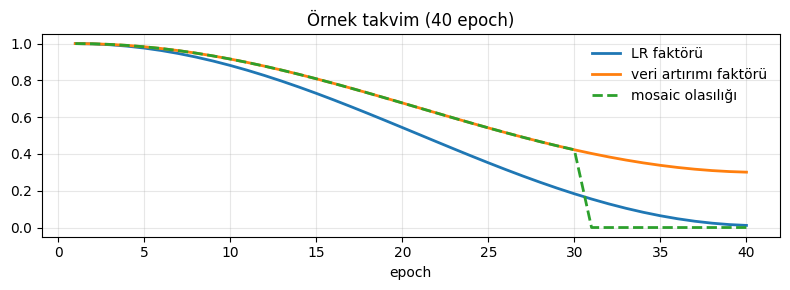

In [27]:
os.environ["AUG_CLOSE_N"] = str(CLOSE_N)
os.environ["AUG_FLOOR"] = str(AUG_FLOOR)
os.environ["PYTHONPATH"] = f"{Path.cwd()}{os.pathsep}{os.environ.get('PYTHONPATH', '')}"
sys.path.insert(0, str(Path.cwd()))

from aug_decay import AugDecayTrainer
from ultralytics import YOLO

# Takvimin önizlemesi: epoch sayısı TIME_H'ye göre belirlenir, burada 40 epoch için gösterilir
E, lrf = 40, 0.01
lf = lambda x: ((1 - math.cos(x * math.pi / E)) / 2) * (lrf - 1) + 1
fac = [AUG_FLOOR + (1 - AUG_FLOOR) * (lf(e) - lrf) / (1 - lrf) for e in range(E)]
mos = [f if e < E - CLOSE_N else 0 for e, f in enumerate(fac)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, E + 1), [lf(e) for e in range(E)], label="LR faktörü", lw=2)
ax.plot(range(1, E + 1), fac, label="veri artırımı faktörü", lw=2)
ax.plot(range(1, E + 1), mos, label="mosaic olasılığı", lw=2, ls="--")
ax.set_xlabel("epoch"); ax.set_title("Örnek takvim (40 epoch)"); ax.legend(frameon=False); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

<a id="5"></a>
## 5 · Eğitim

Eğitim `TIME_H` saatlik bütçeyle çalışır ve her epoch'ta v2 doğrulama kümesinde değerlendirilir.
Kayıtlar: `results.csv` (epoch metrikleri), `aug_log.jsonl`, grafikler ve her 5 epoch'ta bir checkpoint.

**Hata toleransı:** Özel trainer herhangi bir nedenle başlayamazsa, eğitim Ultralytics'in varsayılan trainer'ıyla
(`close_mosaic=10`) otomatik olarak yeniden başlatılır. En az bir epoch tamamlanmışsa, mevcut `last.pt` ile devam edilir.

In [28]:
device = [int(d) for d in DEVICE.split(",")] if DEVICE not in ("cpu", "") else "cpu"
train_args = dict(
    data=str(data_yaml), imgsz=IMGSZ, epochs=EPOCHS, batch=BATCH, device=device,
    workers=0 if SMOKE else 4, cos_lr=True, close_mosaic=CLOSE_N, fliplr=0.5, flipud=0.0, degrees=0.0,
    hsv_v=HSV_V, seed=SEED, amp=not SMOKE, val=True, plots=True, save_period=5, patience=1000,
    project=str(WORK / "runs"), name=RUN_NAME, exist_ok=True,
)
pd.Series({k: v for k, v in train_args.items() if k not in ("project",)}, name="değer").to_frame()

,değer
data,/kaggle/working/data_v2.yaml
imgsz,1280
epochs,300
batch,8
device,"[0, 1]"
workers,4
cos_lr,True
close_mosaic,10
fliplr,0.5000
flipud,0.0000


In [29]:
def find_run():
    """Ultralytics proje klasörlerini iç içe açabildiği için koşu klasörünü adıyla bulur."""
    hits = sorted(WORK.glob(f"**/{RUN_NAME}/weights/last.pt"), key=lambda p: p.stat().st_mtime)
    return hits[-1].parent.parent if hits else None


train_t0 = time.time()
for label, trainer_cls in [("azalan veri artırımı", AugDecayTrainer), ("varsayılan (close_mosaic)", None)]:
    if find_run() is not None:
        log("önceki denemeden last.pt mevcut: eğitim tekrarlanmıyor")
        break
    left_h = TIME_H - (time.time() - train_t0) / 3600
    kw = dict(train_args, time=None if SMOKE else round(left_h, 3))
    if trainer_cls is not None:
        kw["trainer"] = trainer_cls
    log(f"eğitim başlıyor [{label}], bütçe {kw['time']} saat")
    try:
        YOLO(MODEL).train(**kw)
        break
    except Exception as e:
        log(f"eğitim [{label}] hata verdi: {type(e).__name__}: {e}")

RUN = find_run()
assert RUN is not None, "ağırlık üretilmedi"
log(f"eğitim süresi {(time.time() - train_t0) / 3600:.2f} saat | koşu klasörü: {RUN}")

[   1.1 dk] eğitim başlıyor [azalan veri artırımı], bütçe 5.0 saat
Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_v2.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4,

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
[aug-decay] {'epoch': 2, 'epochs': 46, 'lr_factor': 0.9988, 'factor': 0.999, 'mosaic': 0.999, 'scale': 0.5, 'translate': 0.1, 'hsv_h': 0.015, 'hsv_s': 0.699, 'hsv_v': 0.5, 'closed': False}

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/46      8.53G      1.142      1.005     0.9777        191       1280: 100% ━━━━━━━━━━━━ 709/709 2.1it/s 5:440.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 4.5it/s 18.0s0.2s
                   all       1295      31332      0.627        0.6      0.616      0.429
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_l

<a id="6"></a>
## 6 · Eğitim geçmişi

`history.csv`: Ultralytics'in epoch kayıtları + epoch süresi + o epoch'taki veri artırımı değerleri.
Buradaki mAP değerleri Ultralytics'in kendi hesabıdır (yarışma metriğinden birkaç puan yüksek okur);
yarışma metriğiyle değerlendirme Bölüm 7'dedir.

In [30]:
h = pd.read_csv(RUN / "results.csv")
h.columns = h.columns.str.strip()
h["epoch_time_s"] = h["time"].diff().fillna(h["time"])
aug_path = RUN / "aug_log.jsonl"
if aug_path.exists():
    aug = pd.DataFrame([json.loads(s) for s in aug_path.read_text().splitlines() if s.strip()])
    aug = aug.drop_duplicates("epoch", keep="last").drop(columns=["epochs"], errors="ignore")
    h = h.merge(aug.add_prefix("aug_").rename(columns={"aug_epoch": "epoch"}), on="epoch", how="left")
h.to_csv(WORK / "history.csv", index=False)

print(f"{len(h)} epoch · ortalama {h.epoch_time_s.mean():.0f} sn/epoch · toplam {h.epoch_time_s.sum() / 3600:.2f} saat")
show = [c for c in ["epoch", "epoch_time_s", "train/box_loss", "train/cls_loss", "val/box_loss", "val/cls_loss",
                    "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "lr/pg0", "aug_factor",
                    "aug_mosaic", "aug_closed"] if c in h.columns]
h[show]

51 epoch · ortalama 353 sn/epoch · toplam 5.01 saat


,epoch,epoch_time_s,train/box_loss,train/cls_loss,val/box_loss,val/cls_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),lr/pg0,aug_factor,aug_mosaic,aug_closed
0,1,397.5370,1.1304,1.1157,1.0254,0.9617,0.6911,0.5888,0.6403,0.0100,1.0000,1.0000,False
1,2,366.4930,1.1415,1.0046,1.0395,0.9537,0.6268,0.5998,0.6165,0.0200,0.9990,0.9990,False
2,3,359.2800,1.1919,1.0299,1.1000,0.9564,0.6181,0.5425,0.5609,0.0299,0.9970,0.9970,False
3,4,356.9400,1.2008,1.0480,1.0760,0.9352,0.6650,0.5815,0.6213,0.0297,0.9940,0.9940,False
4,5,356.1700,1.1659,0.9708,1.0695,0.8720,0.6945,0.6073,0.6569,0.0295,0.9890,0.9890,False
5,6,356.4400,1.1303,0.9102,1.0266,0.8109,0.7189,0.6340,0.6972,0.0292,0.9820,0.9820,False
6,7,356.1100,1.1144,0.8801,1.0341,0.8047,0.7311,0.6323,0.6959,0.0290,0.9750,0.9750,False
7,8,355.7600,1.1027,0.8624,1.0092,0.7796,0.7181,0.6629,0.7104,0.0286,0.9670,0.9670,False
8,9,355.7100,1.0908,0.8267,1.0062,0.7637,0.7430,0.6564,0.7184,0.0282,0.9570,0.9570,False
9,10,355.7500,1.0598,0.8097,1.0012,0.7479,0.7445,0.6747,0.7291,0.0277,0.9460,0.9460,False


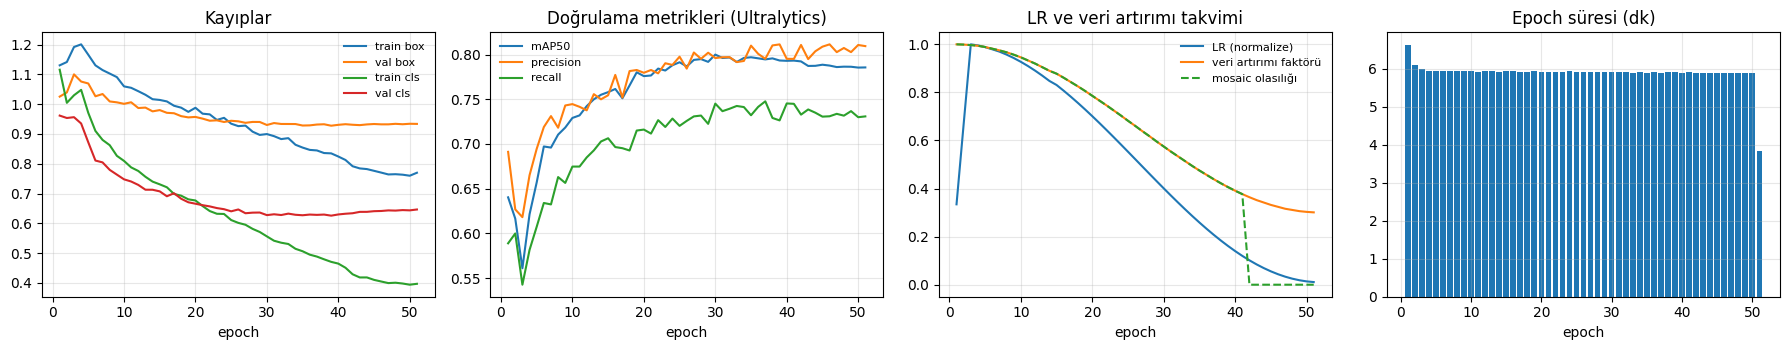

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for c, lbl in [("train/box_loss", "train box"), ("val/box_loss", "val box"),
               ("train/cls_loss", "train cls"), ("val/cls_loss", "val cls")]:
    if c in h: axes[0].plot(h.epoch, h[c], label=lbl)
axes[0].set_title("Kayıplar"); axes[0].legend(frameon=False, fontsize=8)
for c, lbl in [("metrics/mAP50(B)", "mAP50"), ("metrics/precision(B)", "precision"), ("metrics/recall(B)", "recall")]:
    if c in h: axes[1].plot(h.epoch, h[c], label=lbl)
axes[1].set_title("Doğrulama metrikleri (Ultralytics)"); axes[1].legend(frameon=False, fontsize=8)
if "lr/pg0" in h: axes[2].plot(h.epoch, h["lr/pg0"] / h["lr/pg0"].max(), label="LR (normalize)")
if "aug_factor" in h: axes[2].plot(h.epoch, h["aug_factor"], label="veri artırımı faktörü")
if "aug_mosaic" in h: axes[2].plot(h.epoch, h["aug_mosaic"], ls="--", label="mosaic olasılığı")
axes[2].set_title("LR ve veri artırımı takvimi"); axes[2].legend(frameon=False, fontsize=8)
axes[3].bar(h.epoch, h.epoch_time_s / 60); axes[3].set_title("Epoch süresi (dk)")
for ax in axes: ax.set_xlabel("epoch"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

<a id="7"></a>
## 7 · Değerlendirme

### 7.1 Yarışma metriği
Kaggle kuralının birebir uygulaması: sınıf bazında güvene göre sıralama, IoU ≥ 0,5 ile açgözlü eşleştirme,
eşleşmemiş 200 px² altı tahminler yok sayılır, all-point interpolasyonlu AP, dört sınıfın ortalaması.
İsteğe bağlı görüntü ağırlıklarını destekler.

### 7.2 Test ağırlıklı doğrulama
v2 doğrulama kümesi test dağılımını olabildiğince taklit eder; ancak etiketli veride yalnızca 224 karanlık 1400×788
görüntü bulunduğundan tam eşleşme mümkün değildir. Bu yüzden her doğrulama görüntüsüne
`w = p_test(katman) / p_val(katman)` ağırlığı verilir (katman = çözünürlük × karanlık/aydınlık).
**Model seçimi test ağırlıklı mAP'e göre yapılır.**

In [32]:
def image_info(folder, ids):
    rows = []
    for i in ids:
        with Image.open(DS / folder / f"{i}.jpg") as im:
            w, h_ = im.size
            im.draft("L", (128, 128))
            b = float(np.asarray(im.convert("L").resize((64, 64))).mean())
        rows.append((i, w, h_, f"{w}x{h_}" + (" · karanlık" if b < DARK_THR else " · aydınlık")))
    return pd.DataFrame(rows, columns=["image_id", "W", "H", "katman"]).set_index("image_id")


val_info, test_info = image_info("images/train", val_ids), image_info("images/test", test_ids)
p_test, p_val = test_info.katman.value_counts(normalize=True), val_info.katman.value_counts(normalize=True)
w_img = val_info.katman.map((p_test / p_val).fillna(0.0)).fillna(0.0)
w_img = w_img * len(w_img) / w_img.sum()
log(f"etkin örnek sayısı (ESS): {w_img.sum() ** 2 / (w_img ** 2).sum():.0f} / {len(w_img)}")

strata = pd.DataFrame({"val %": p_val * 100, "test %": p_test * 100,
                       "ağırlıklı val %": w_img.groupby(val_info.katman).sum() / w_img.sum() * 100}).fillna(0)
strata.sort_values("test %", ascending=False).round(2)

[ 302.8 dk] etkin örnek sayısı (ESS): 1167 / 1295


,val %,test %,ağırlıklı val %
katman,,,
1400x788 · aydınlık,29.4200,26.1100,26.1100
1360x765 · aydınlık,28.0300,25.8300,25.8300
1400x788 · karanlık,8.6500,17.9400,17.9400
1400x1050 · aydınlık,13.6700,12.2300,12.2300
1916x1078 · aydınlık,8.0300,7.1300,7.1300
960x540 · aydınlık,7.9500,7.0300,7.0300
1920x1080 · aydınlık,2.6300,2.3100,2.3100
1400x1050 · karanlık,0.7700,0.7100,0.7100
1360x765 · karanlık,0.4600,0.4200,0.4200


In [33]:
# Doğrulama kümesinin gerçek kutuları (piksel, sol üst köşe)
gt_rows = []
for i in val_ids:
    W, H = val_info.loc[i, ["W", "H"]]
    for s in (DS / "labels/train" / f"{i}.txt").read_text().splitlines():
        if s.strip():
            c, cx, cy, bw, bh = s.split()
            cx, cy, bw, bh = float(cx) * W, float(cy) * H, float(bw) * W, float(bh) * H
            gt_rows.append((i, CLASSES[int(c)], cx - bw / 2, cy - bh / 2, bw, bh))
gt = pd.DataFrame(gt_rows, columns=["image_id", "label", "x", "y", "w", "h"])


def _iou(b, B):
    x1 = np.maximum(b[0], B[:, 0]); y1 = np.maximum(b[1], B[:, 1])
    x2 = np.minimum(b[0] + b[2], B[:, 0] + B[:, 2]); y2 = np.minimum(b[1] + b[3], B[:, 1] + B[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    return inter / np.maximum(b[2] * b[3] + B[:, 2] * B[:, 3] - inter, 1e-9)


def evaluate(pred, ids, weights=None, min_area=200.0):
    """Yarışma tarzı mAP@0.5 (isteğe bağlı görüntü ağırlıklarıyla)."""
    ids = list(ids)
    w = pd.Series(1.0, index=ids) if weights is None else weights.reindex(ids).fillna(0.0)
    keep = set(w.index[w > 0])
    g_all, p_all = gt[gt.image_id.isin(keep)], pred[pred.image_id.isin(keep)]
    ap = {}
    for c in CLASSES:
        g = g_all[g_all.label == c]
        p = p_all[p_all.label == c].sort_values("conf", ascending=False, kind="mergesort")
        boxes = {k: v[["x", "y", "w", "h"]].to_numpy(float) for k, v in g.groupby("image_id")}
        used = {k: np.zeros(len(v), bool) for k, v in boxes.items()}
        npos = float(w.reindex(g.image_id).sum())
        if npos == 0:
            ap[c] = float("nan"); continue
        tp, fp = np.zeros(len(p)), np.zeros(len(p))
        pw = w.reindex(p.image_id).to_numpy()
        for k, (img, b) in enumerate(zip(p.image_id.to_numpy(), p[["x", "y", "w", "h"]].to_numpy(float))):
            B, j, best = boxes.get(img), -1, 0.0
            if B is not None:
                ious = _iou(b, B); ious[used[img]] = -1.0
                j = int(np.argmax(ious)); best = ious[j]
            if best >= 0.5:
                used[img][j] = True; tp[k] = pw[k]
            elif b[2] * b[3] >= min_area:
                fp[k] = pw[k]
        ctp, cfp = np.cumsum(tp), np.cumsum(fp)
        rec = np.concatenate([[0.0], ctp / npos, [1.0]])
        prec = np.concatenate([[0.0], ctp / np.maximum(ctp + cfp, 1e-12), [0.0]])
        prec = np.maximum.accumulate(prec[::-1])[::-1]
        idx = np.where(rec[1:] != rec[:-1])[0]
        ap[c] = float(np.sum((rec[idx + 1] - rec[idx]) * prec[idx + 1]))
    vals = [v for v in ap.values() if not np.isnan(v)]
    return {"mAP": float(np.mean(vals)) if vals else float("nan"), **ap}


PRED_KW = dict(conf=0.001, iou=0.7, max_det=1000, device=0 if torch.cuda.is_available() else "cpu",
               quantize=16 if torch.cuda.is_available() else None, verbose=False)   # FP16 on GPU (`half` is deprecated)


def predict(weights, folder, ids, imgsz=IMGSZ, augment=False):
    """Görüntü görüntü tahmin (liste kaynağı Ultralytics'te tek batch sayıldığı için bellek taşar)."""
    m = YOLO(str(weights))
    rows = []
    for i in ids:
        r = m.predict(str(DS / folder / f"{i}.jpg"), imgsz=imgsz, augment=augment, **PRED_KW)[0]
        for (x1, y1, x2, y2), c, s in zip(r.boxes.xyxy.tolist(), r.boxes.cls.tolist(), r.boxes.conf.tolist()):
            if x2 - x1 < 1 or y2 - y1 < 1:      # görüntü kenarında sıfır boyuta kırpılmış kutu: geçersiz
                continue
            rows.append((i, CLASSES[int(c)], round(s, 5), round(x1, 1), round(y1, 1),
                         round(x2 - x1, 1), round(y2 - y1, 1)))
    return pd.DataFrame(rows, columns=["image_id", "label", "conf", "x", "y", "w", "h"])


def tile_origins(length, size, overlap):
    """Tile başlangıç noktaları; son tile kenara hizalanır."""
    if length <= size:
        return [0]
    step = max(1, int(size * (1 - overlap)))
    return sorted(set(list(range(0, length - size, step)) + [length - size]))


def owned_spans(origins, size, length):
    """Her tile'ın sahip olduğu aralık: komşu tile'larla örtüşmenin ortasından bölünür (Yıldırım'ın owner filter'ı)."""
    spans = []
    for k, o in enumerate(origins):
        lo = 0.0 if k == 0 else (origins[k - 1] + size + o) / 2
        hi = float(length) + 1 if k == len(origins) - 1 else (o + size + origins[k + 1]) / 2
        spans.append((lo, hi))
    return spans


def predict_sahi(weights, folder, ids, size=SAHI_SLICE, overlap=SAHI_OVERLAP, tile_imgsz=SAHI_IMGSZ):
    """SAHI (Akyon ve ark., 2022): tam görüntü + büyütülerek tahmin edilen tile'lar (owner filter), sınıf bazlı NMS ile birleştirilir."""
    import torchvision
    m = YOLO(str(weights))
    rows = []
    for i in ids:
        img = np.ascontiguousarray(np.asarray(Image.open(DS / folder / f"{i}.jpg").convert("RGB"))[:, :, ::-1])  # BGR
        H, W = img.shape[:2]
        B, S, C = [], [], []
        xs, ys = tile_origins(W, size, overlap), tile_origins(H, size, overlap)
        own_x, own_y = owned_spans(xs, size, W), owned_spans(ys, size, H)
        views = [(img, 0, 0, IMGSZ, None)] + [
            (np.ascontiguousarray(img[y0:y0 + size, x0:x0 + size]), x0, y0, tile_imgsz, (own_x[a], own_y[b_]))
            for b_, y0 in enumerate(ys) for a, x0 in enumerate(xs)]
        for view, dx, dy, sz, own in views:
            r = m.predict(view, imgsz=sz, **PRED_KW)[0]
            bx = r.boxes.xyxy.cpu().numpy() + np.array([dx, dy, dx, dy], dtype=np.float32)
            sc_, cl_ = r.boxes.conf.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int)
            if own is not None and len(bx):        # owner filter: keep boxes whose centre lies in this tile's own span
                cx, cy = (bx[:, 0] + bx[:, 2]) / 2, (bx[:, 1] + bx[:, 3]) / 2
                k = (cx >= own[0][0]) & (cx < own[0][1]) & (cy >= own[1][0]) & (cy < own[1][1])
                bx, sc_, cl_ = bx[k], sc_[k], cl_[k]
            B.append(bx); S.append(sc_); C.append(cl_)
        b, sc, cl = np.concatenate(B), np.concatenate(S), np.concatenate(C)
        if len(b):
            keep = torchvision.ops.batched_nms(torch.from_numpy(b).float(), torch.from_numpy(sc).float(),
                                               torch.from_numpy(cl), MERGE_IOU).numpy()[:1000]
            for (x1, y1, x2, y2), s_, c_ in zip(b[keep], sc[keep], cl[keep]):
                x1, y1, x2, y2 = max(0.0, x1), max(0.0, y1), min(float(W), x2), min(float(H), y2)
                if x2 - x1 < 1 or y2 - y1 < 1:
                    continue
                rows.append((i, CLASSES[int(c_)], round(float(s_), 5), round(float(x1), 1), round(float(y1), 1),
                             round(float(x2 - x1), 1), round(float(y2 - y1), 1)))
    return pd.DataFrame(rows, columns=["image_id", "label", "conf", "x", "y", "w", "h"])

In [34]:
subsets = {n: read_ids(f"{n}.txt") for n in ["val_1400x788", "val_dark", "val_1400x788_dark"] if (DS / f"{n}.txt").exists()}
val_preds, scores = {}, {}
for tag in ["last", "best"]:
    wpath = RUN / "weights" / f"{tag}.pt"
    if not wpath.exists():
        continue
    pv = predict(wpath, "images/train", val_ids)
    pv.to_csv(WORK / f"preds_val_{tag}.csv", index=False)
    val_preds[tag] = pv
    sc = {"val (ağırlıksız)": evaluate(pv, val_ids), "val (test ağırlıklı)": evaluate(pv, val_ids, w_img)}
    for n, ids in subsets.items():
        sc[n] = evaluate(pv, ids)
    scores[tag] = sc
    log(f"{tag}.pt: test ağırlıklı mAP@0.5 = {sc['val (test ağırlıklı)']['mAP']:.4f}")

chosen = max(scores, key=lambda t: scores[t]["val (test ağırlıklı)"]["mAP"])
table = pd.DataFrame({(t, k): v for t, sc in scores.items() for k, v in sc.items()}).T
table.index.names = ["ağırlık", "küme"]
table

[ 303.7 dk] last.pt: test ağırlıklı mAP@0.5 = 0.7447
[ 304.6 dk] best.pt: test ağırlıklı mAP@0.5 = 0.7566


mAP    car    van  truck    bus
ağırlık küme                                                   
last    val (ağırlıksız)     0.7534 0.8902 0.6029 0.7159 0.8045
        val (test ağırlıklı) 0.7447 0.8886 0.5943 0.7083 0.7875
        val_1400x788         0.7677 0.8593 0.5878 0.7938 0.8298
        val_dark             0.6324 0.8671 0.3793 0.6148 0.6685
        val_1400x788_dark    0.6324 0.8641 0.3740 0.6254 0.6660
best    val (ağırlıksız)     0.7652 0.9026 0.6269 0.7212 0.8103
        val (test ağırlıklı) 0.7566 0.9010 0.6184 0.7131 0.7939
        val_1400x788         0.7829 0.8774 0.6235 0.7911 0.8395
        val_dark             0.6398 0.8756 0.4004 0.6195 0.6635
        val_1400x788_dark    0.6392 0.8722 0.3911 0.6299 0.6636

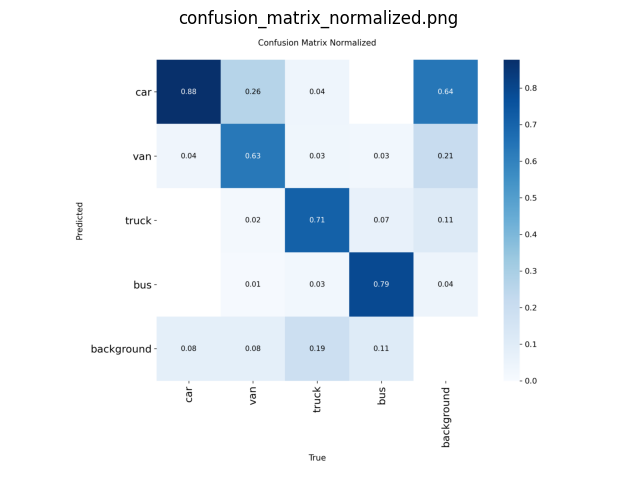

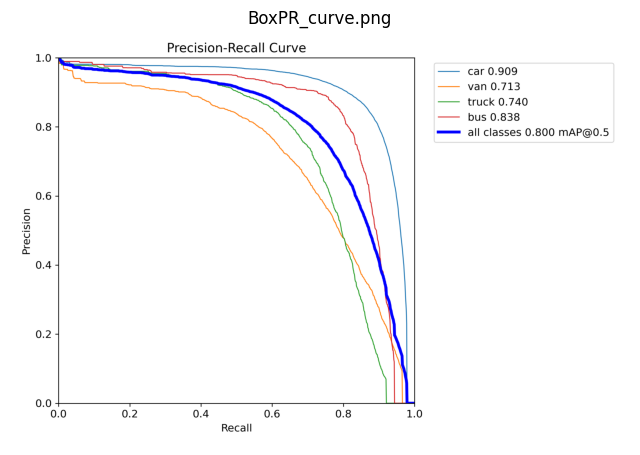

In [35]:
for name in ["confusion_matrix_normalized.png", "BoxPR_curve.png"]:
    if (RUN / name).exists():
        fig = plt.figure(figsize=(8, 6)); plt.imshow(plt.imread(RUN / name)); plt.axis("off"); plt.title(name); plt.show()

<a id="8"></a>
## 8 · Tahmin iyileştirmeleri: çözünürlük, TTA, SAHI

Yeniden eğitim gerektirmeyen dört tahmin yöntemi, seçilen ağırlıkla doğrulama kümesinde **yarışma metriğiyle** karşılaştırılır.
Kazanan (test ağırlıklı mAP'i en yüksek olan) yöntem Bölüm 9'da test setine uygulanır.

| Yöntem | Açıklama | Gerekçe |
|---|---|---|
| **A · 1280** | Eğitim çözünürlüğünde düz tahmin | Referans |
| **B · 1536** | Tam görüntü, 1536'da | Araçları 1,2× büyütür; eğitimdeki `scale` artırımı bu aralığı kapsar |
| **C · TTA@1536** | Ultralytics TTA: ölçekler 1,0 / 0,83 / 0,67 + yatay çevirme | TTA görüntüyü **küçülterek** çalıştığı için 1280 yerine 1536'da uygulanır (1536 / 1275 / 1030) |
| **D · SAHI** | 800 px tile'lar 1280'de (≈1,6× büyütme, owner filter) + tam görüntü 1280, sınıf bazlı NMS ile birleştirme | Küçük nesnelerde kanıtlı yöntem (Akyon, Altınuç, Temizel, ICIP 2022); ekipte RF-DETR tile'larla 0,79–0,80 |

Ardından her yöntemin tahminleri üzerinde **NMS IoU eşiği 0,50–0,70 arasında taranır** (yeniden tahmin gerekmez; 0,70'te üretilen kutulara daha sıkı sınıf bazlı NMS uygulanır). Test setine en iyi **yöntem × eşik** kombinasyonu uygulanır.

Her deney bağımsız korunur: biri hata verirse atlanır, diğerleri ve ana submission etkilenmez.

In [36]:
METHODS = {
    "A · 1280":     ("a_1280",     lambda w, f, ids: predict(w, f, ids, imgsz=IMGSZ)),
    "B · 1536":     ("b_1536",     lambda w, f, ids: predict(w, f, ids, imgsz=HI_IMGSZ)),
    "C · TTA@1536": ("c_tta1536",  lambda w, f, ids: predict(w, f, ids, imgsz=HI_IMGSZ, augment=True)),
    "D · SAHI":     ("d_sahi",     lambda w, f, ids: predict_sahi(w, f, ids)),
}
w_chosen = RUN / "weights" / f"{chosen}.pt"
method_scores, method_time, method_preds = {"A · 1280": scores[chosen]}, {}, {"A · 1280": val_preds[chosen]}
for name, (slug, fn) in list(METHODS.items())[1:]:
    t = time.time()
    try:
        pv = fn(w_chosen, "images/train", val_ids)
        pv.to_csv(WORK / f"preds_val_{chosen}_{slug}.csv", index=False)
        sc = {"val (ağırlıksız)": evaluate(pv, val_ids), "val (test ağırlıklı)": evaluate(pv, val_ids, w_img)}
        for n, ids in subsets.items():
            sc[n] = evaluate(pv, ids)
        method_scores[name], method_preds[name] = sc, pv
        method_time[name] = round((time.time() - t) / 60, 1)
        log(f"{name}: test ağırlıklı mAP@0.5 = {sc['val (test ağırlıklı)']['mAP']:.4f} ({method_time[name]} dk)")
    except Exception as e:
        log(f"{name} atlandı: {type(e).__name__}: {e}")

winner = max(method_scores, key=lambda k: method_scores[k]["val (test ağırlıklı)"]["mAP"])
log(f"kazanan yöntem: {winner}")
mt = pd.DataFrame({(m, k): v for m, sc in method_scores.items() for k, v in sc.items()}).T
mt.index.names = ["yöntem", "küme"]
mt

[ 305.9 dk] B · 1536: test ağırlıklı mAP@0.5 = 0.7722 (1.3 dk)
[ 308.1 dk] C · TTA@1536: test ağırlıklı mAP@0.5 = 0.7874 (2.2 dk)
[ 311.8 dk] D · SAHI: test ağırlıklı mAP@0.5 = 0.7882 (3.7 dk)
[ 311.8 dk] kazanan yöntem: D · SAHI


mAP    car    van  truck    bus
yöntem       küme                                                   
A · 1280     val (ağırlıksız)     0.7652 0.9026 0.6269 0.7212 0.8103
             val (test ağırlıklı) 0.7566 0.9010 0.6184 0.7131 0.7939
             val_1400x788         0.7829 0.8774 0.6235 0.7911 0.8395
             val_dark             0.6398 0.8756 0.4004 0.6195 0.6635
             val_1400x788_dark    0.6392 0.8722 0.3911 0.6299 0.6636
B · 1536     val (ağırlıksız)     0.7798 0.9072 0.6470 0.7377 0.8273
             val (test ağırlıklı) 0.7722 0.9054 0.6408 0.7325 0.8100
             val_1400x788         0.7978 0.8827 0.6426 0.8129 0.8531
             val_dark             0.6728 0.8771 0.4671 0.6765 0.6705
             val_1400x788_dark    0.6756 0.8746 0.4740 0.6846 0.6693
C · TTA@1536 val (ağırlıksız)     0.7940 0.9109 0.6792 0.7481 0.8380
             val (test ağırlıklı) 0.7874 0.9095 0.6732 0.7433 0.8236
             val_1400x788         0.8120 0.8950 0.6781 0.8105 0.8644
             val_dark             0.7023 0.8870 0.5090 0.7009 0.7123
             val_1400x788_dark    0.7016 0.8871 0.5034 0.7047 0.7114
D · SAHI     val (ağırlıksız)     0.7956 0.9156 0.6756 0.7504 0.8410
             val (test ağırlıklı) 0.7882 0.9141 0.6671 0.7453 0.8263
             val_1400x788         0.8177 0.8989 0.6790 0.8282 0.8646
             val_dark             0.6770 0.8866 0.4481 0.6754 0.6979
             val_1400x788_dark    0.6817 0.8874 0.4450 0.6943 0.7001

In [37]:
import torchvision

CLS_IDX = {c: k for k, c in enumerate(CLASSES)}


def renms(df, thr):
    """Kaydedilmiş kutulara daha sıkı sınıf bazlı NMS uygular (0,70'ten düşük eşikler için)."""
    if df.empty or thr >= 0.7:
        return df
    keep_idx = []
    for _, g in df.groupby("image_id", sort=False):
        b = torch.tensor(g[["x", "y", "w", "h"]].to_numpy(), dtype=torch.float32)
        b[:, 2:] += b[:, :2]
        k = torchvision.ops.batched_nms(b, torch.tensor(g.conf.to_numpy(), dtype=torch.float32),
                                        torch.tensor(g.label.map(CLS_IDX).to_numpy()), thr).numpy()
        keep_idx.extend(g.index[k])
    return df.loc[keep_idx]


nms_rows = []
for name, pv in method_preds.items():
    for thr in NMS_SWEEP:
        try:
            nms_rows.append({"yöntem": name, "NMS IoU": thr,
                             "test ağırlıklı mAP": evaluate(renms(pv, thr), val_ids, w_img)["mAP"]})
        except Exception as e:
            log(f"NMS taraması {name} @ {thr} atlandı: {type(e).__name__}: {e}")
nms_table = pd.DataFrame(nms_rows).pivot(index="yöntem", columns="NMS IoU", values="test ağırlıklı mAP")
best_combo = max(nms_rows, key=lambda r: r["test ağırlıklı mAP"])
winner, winner_nms = best_combo["yöntem"], best_combo["NMS IoU"]
log(f"en iyi kombinasyon: {winner} · NMS {winner_nms} → test ağırlıklı mAP {best_combo['test ağırlıklı mAP']:.4f}")
nms_table

[ 314.2 dk] en iyi kombinasyon: C · TTA@1536 · NMS 0.6 → test ağırlıklı mAP 0.7894


NMS IoU,0.5000,0.5500,0.6000,0.6500,0.7000
yöntem,,,,,
A · 1280,0.7547,0.7557,0.7568,0.7572,0.7566
B · 1536,0.7699,0.7711,0.7720,0.7725,0.7722
C · TTA@1536,0.7877,0.7885,0.7894,0.7892,0.7874
D · SAHI,0.7855,0.7870,0.7882,0.7882,0.7882


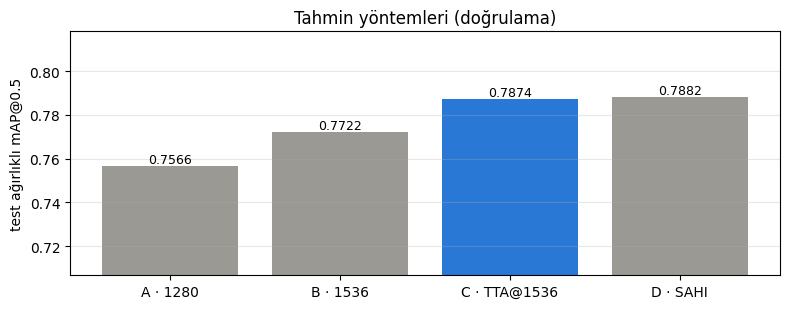

In [38]:
tw = pd.Series({m: sc["val (test ağırlıklı)"]["mAP"] for m, sc in method_scores.items()})
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(tw.index, tw.values, color=["#9a9994" if m != winner else "#2a78d6" for m in tw.index])
for b_, v in zip(bars, tw.values):
    ax.text(b_.get_x() + b_.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(max(0, tw.min() - 0.05), min(1, tw.max() + 0.03))
ax.set_ylabel("test ağırlıklı mAP@0.5"); ax.set_title("Tahmin yöntemleri (doğrulama)"); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

<a id="9"></a>
## 9 · Test tahmini ve submission

Seçilen ağırlıkla test görüntüleri önce düz 1280'de (yedek), kazanan yöntem farklıysa onunla da tahmin edilir.
`submission.csv` kazanan yöntemden üretilir. Dosya yarışma formatına göre doğrulanır: her test görüntüsü için bir satır,
tahmin yoksa `none`, `label conf x y w h` grupları, `0 ≤ conf ≤ 1`, `w, h > 0`.

In [39]:
def write_submission(test_pred, path):
    s = (test_pred.label + " " + test_pred.conf.astype(str) + " " + test_pred.x.astype(str) + " "
         + test_pred.y.astype(str) + " " + test_pred.w.astype(str) + " " + test_pred.h.astype(str))
    strings = s.groupby(test_pred.image_id).agg(" ".join)
    ids = sorted(test_ids)
    sub = pd.DataFrame({"image_id": ids, "PredictionString": [strings.get(i, "none") for i in ids]})
    assert len(sub) == len(set(test_ids)) and sub.PredictionString.str.len().gt(0).all()
    for ps in sub.PredictionString:
        if ps != "none":
            t = ps.split()
            assert len(t) % 6 == 0
            for k in range(0, len(t), 6):
                assert t[k] in CLASSES and 0 <= float(t[k + 1]) <= 1 and float(t[k + 4]) > 0 and float(t[k + 5]) > 0
    sub.to_csv(path, index=False)
    return sub


def run_test(name, nms=0.7):
    slug, fn = METHODS[name]
    pt = fn(w_chosen, "images/test", test_ids)
    pt.to_csv(WORK / f"preds_test_{chosen}_{slug}.csv", index=False)      # ham tahminler (NMS 0,70; ensemble için)
    pt = renms(pt, nms)
    path = WORK / f"submission_{chosen}_{slug}_nms{int(nms * 100)}.csv"
    sub = write_submission(pt, path)
    log(f"{path.name}: {len(sub)} satır, {int((sub.PredictionString == 'none').sum())} boş, {len(pt)} kutu")
    return path


final_method, final_nms, final_path = "A · 1280", 0.7, run_test("A · 1280")        # yedek: her durumda yazılır
if (winner, winner_nms) != ("A · 1280", 0.7):
    try:
        final_path = run_test(winner, winner_nms) if winner != "A · 1280" else None
        if final_path is None:                                      # aynı yöntem, farklı NMS: yeniden tahmin gerekmez
            pt = renms(pd.read_csv(WORK / f"preds_test_{chosen}_a_1280.csv"), winner_nms)
            final_path = WORK / f"submission_{chosen}_a_1280_nms{int(winner_nms * 100)}.csv"
            write_submission(pt, final_path)
        final_method, final_nms = winner, winner_nms
    except Exception as e:
        final_path = WORK / f"submission_{chosen}_a_1280_nms70.csv"
        log(f"{winner} test tahmini başarısız, yedek kullanılıyor: {type(e).__name__}: {e}")

shutil.copy(final_path, WORK / "submission.csv")
json.dump({"chosen_weights": chosen, "method": final_method, "nms_iou": final_nms, "nms_sweep": nms_rows,
           "weight_scores": scores, "method_scores": method_scores, "aug_floor": AUG_FLOOR, "hsv_v": HSV_V,
           "method_minutes": method_time, "rfs": {"t": RFS_T, "f_c": f_c, "r_c": r_c, "extra_images": extra},
           "imgsz": IMGSZ, "time_h": TIME_H, "model": MODEL, "ultralytics": ultralytics.__version__},
          open(WORK / "scores.json", "w"), indent=2)
log(f"submission.csv ← {chosen}.pt · {final_method} · NMS {final_nms}")
pd.read_csv(WORK / "submission.csv").head()

[ 315.3 dk] submission_best_a_1280_nms70.csv: 2118 satır, 2 boş, 324965 kutu
[ 318.3 dk] submission_best_c_tta1536_nms60.csv: 2118 satır, 1 boş, 405582 kutu
[ 318.3 dk] submission.csv ← best.pt · C · TTA@1536 · NMS 0.6


,image_id,PredictionString
0,img_000001,car 0.9082 1158.1 603.0 159.4 131.9 car 0.8925...
1,img_000002,car 0.92236 403.8 552.5 491.4 212.5 truck 0.87...
2,img_000003,van 0.90674 935.2 517.3 103.9 57.4 car 0.90137...
3,img_000004,car 0.89111 1327.5 616.4 99.8 52.4 truck 0.886...
4,img_000008,bus 0.93994 487.6 559.6 198.7 131.2 bus 0.9384...


<a id="10"></a>
## 10 · Özet

In [40]:
best = method_scores[final_method]          # yöntem skorları NMS 0,70'te; seçilen eşiğin skoru nms_sweep'te
summary = pd.Series({
    "model": MODEL,
    "seçilen ağırlık": f"{chosen}.pt",
    "tahmin yöntemi": final_method,
    "NMS IoU": final_nms,
    "test ağırlıklı val mAP@0.5": round(best["val (test ağırlıklı)"]["mAP"], 4),
    "ağırlıksız val mAP@0.5": round(best["val (ağırlıksız)"]["mAP"], 4),
    **{f"AP {c} (test ağırlıklı)": round(best["val (test ağırlıklı)"][c], 4) for c in CLASSES},
    "epoch": len(h),
    "ortalama epoch süresi (sn)": round(h.epoch_time_s.mean()),
    "RFS ek görüntü": extra,
    "toplam süre (saat)": round((time.time() - T0) / 3600, 2),
}, name="değer")
if not SMOKE:
    shutil.rmtree(DS, ignore_errors=True)       # çıktıyı küçük tut: yalnızca ağırlıklar, csv ve json kalır
summary.to_frame()

,değer
model,yolo11m.pt
seçilen ağırlık,best.pt
tahmin yöntemi,C · TTA@1536
NMS IoU,0.6000
test ağırlıklı val mAP@0.5,0.7874
ağırlıksız val mAP@0.5,0.7940
AP car (test ağırlıklı),0.9095
AP van (test ağırlıklı),0.6732
AP truck (test ağırlıklı),0.7433
AP bus (test ağırlıklı),0.8236


**Çıktılar** (`/kaggle/working`)

| Dosya | İçerik |
|---|---|
| `submission.csv` | Seçilen ağırlık ve kazanan tahmin yöntemiyle yarışma formatında test tahminleri |
| `submission_<ağırlık>_<yöntem>_nms<eşik>.csv` | Düz 1280 / NMS 0,70 tahmini (yedek) ve kazanan yöntem × NMS kombinasyonunun submission'ı |
| `scores.json` | Yarışma metriğiyle ağırlık ve yöntem skorları, süreler, RFS parametreleri |
| `history.csv` | Epoch bazında metrikler, süre ve veri artırımı değerleri |
| `preds_val_*.csv`, `preds_test_*.csv` | Ham tahminler (`image_id,label,conf,x,y,w,h`) |
| `runs/y11m_v2/` | `last.pt`, `best.pt`, 5 epoch'luk checkpoint'ler, eğitim grafikleri |

**Sonraki adımlar:** YOLO11s ve YOLO11m karşılaştırması, car ↔ van karışıklığı için ikinci aşama sınıflandırıcı, P2 head.